# Group Work - Advanced Data Analysis and Machine Learning 
**Topic:** NASA Turbofan Level A2  
**Team:** Ahson Anwaar, Ondřej Beneš, Dan Valníček  
**Date:** 11.9.2026

## Imports

In [105]:
!mamba install pandas matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.329 seconds
All requested packages already installed.


## Data loading
Loading all the data in the format specified by the attached dataset description.

In [106]:
columns = [
    "unit number",
    "time in cycles",
    "operational setting 1",
    "operational setting 2",
    "operational setting 3",
    *[f"sensor measurement {i}" for i in range(1, 22)],
]

# Load all datasets
train = {}
test = {}
rul = {}

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    train[fd] = pd.read_csv(
        f"./data/train_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=columns,
    )

    test[fd] = pd.read_csv(
        f"./data/test_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=columns,
    )

    rul[fd] = pd.read_csv(
        f"./data/RUL_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=["RUL"],
    )


for fd in train:
    print(f"{fd}:")
    print(f"  Train: {train[fd].shape}")
    print(f"  Test:  {test[fd].shape}")
    print(f"  RUL:   {rul[fd].shape}")
    print()

print(train["FD001"].head())

FD001:
  Train: (20631, 26)
  Test:  (13096, 26)
  RUL:   (100, 1)

FD002:
  Train: (53759, 26)
  Test:  (33991, 26)
  RUL:   (259, 1)

FD003:
  Train: (24720, 26)
  Test:  (16596, 26)
  RUL:   (100, 1)

FD004:
  Train: (61249, 26)
  Test:  (41214, 26)
  RUL:   (248, 1)

   unit number  time in cycles  operational setting 1  operational setting 2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational setting 3  sensor measurement 1  sensor measurement 2  \
0                  100.0                518.67                641.82   
1                  100.0                518.67                642.15   
2                  100.0       

## Exploration

### Initial data visualization

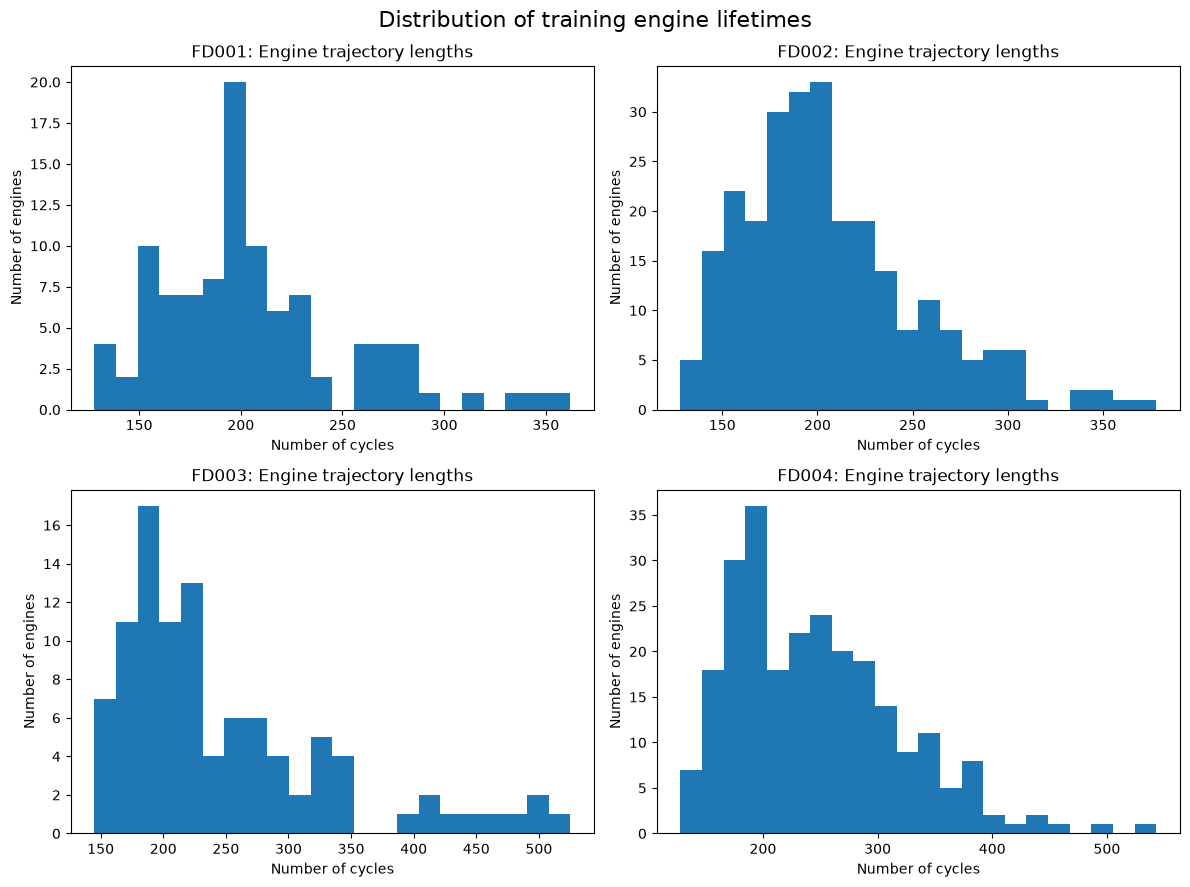

In [107]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for i, fd in enumerate(train):

    trajectory_lengths = (
        train[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )

    axes[i].hist(
        trajectory_lengths,
        bins=22
    )

    axes[i].set_title(f"{fd}: Engine trajectory lengths")
    axes[i].set_xlabel("Number of cycles")
    axes[i].set_ylabel("Number of engines")

fig.suptitle(
    "Distribution of training engine lifetimes",
    fontsize=16
)

plt.tight_layout()
plt.show()

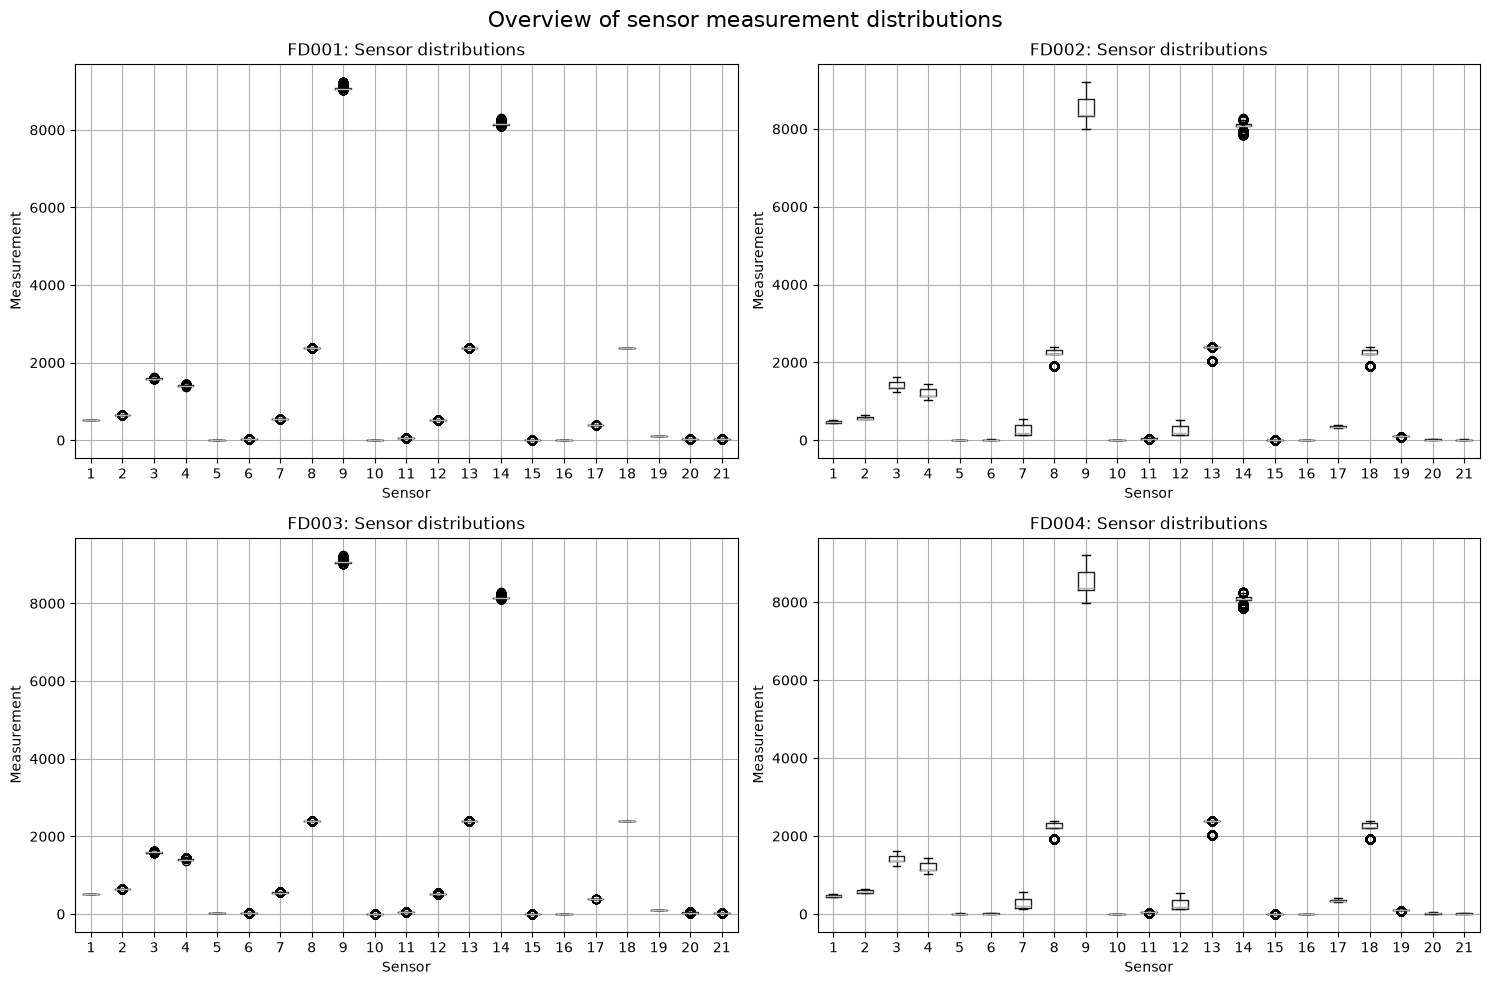

In [108]:
sensor_columns = [
    f"sensor measurement {i}"
    for i in range(1, 22)
]

sensor_numbers = list(range(1, 22))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

axes = axes.flatten()

for i, fd in enumerate(train):

    train[fd][sensor_columns].boxplot(
        ax=axes[i]
    )

    axes[i].set_xticklabels(
        sensor_numbers
    )

    axes[i].set_title(f"{fd}: Sensor distributions")
    axes[i].set_xlabel("Sensor")
    axes[i].set_ylabel("Measurement")

fig.suptitle(
    "Overview of sensor measurement distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

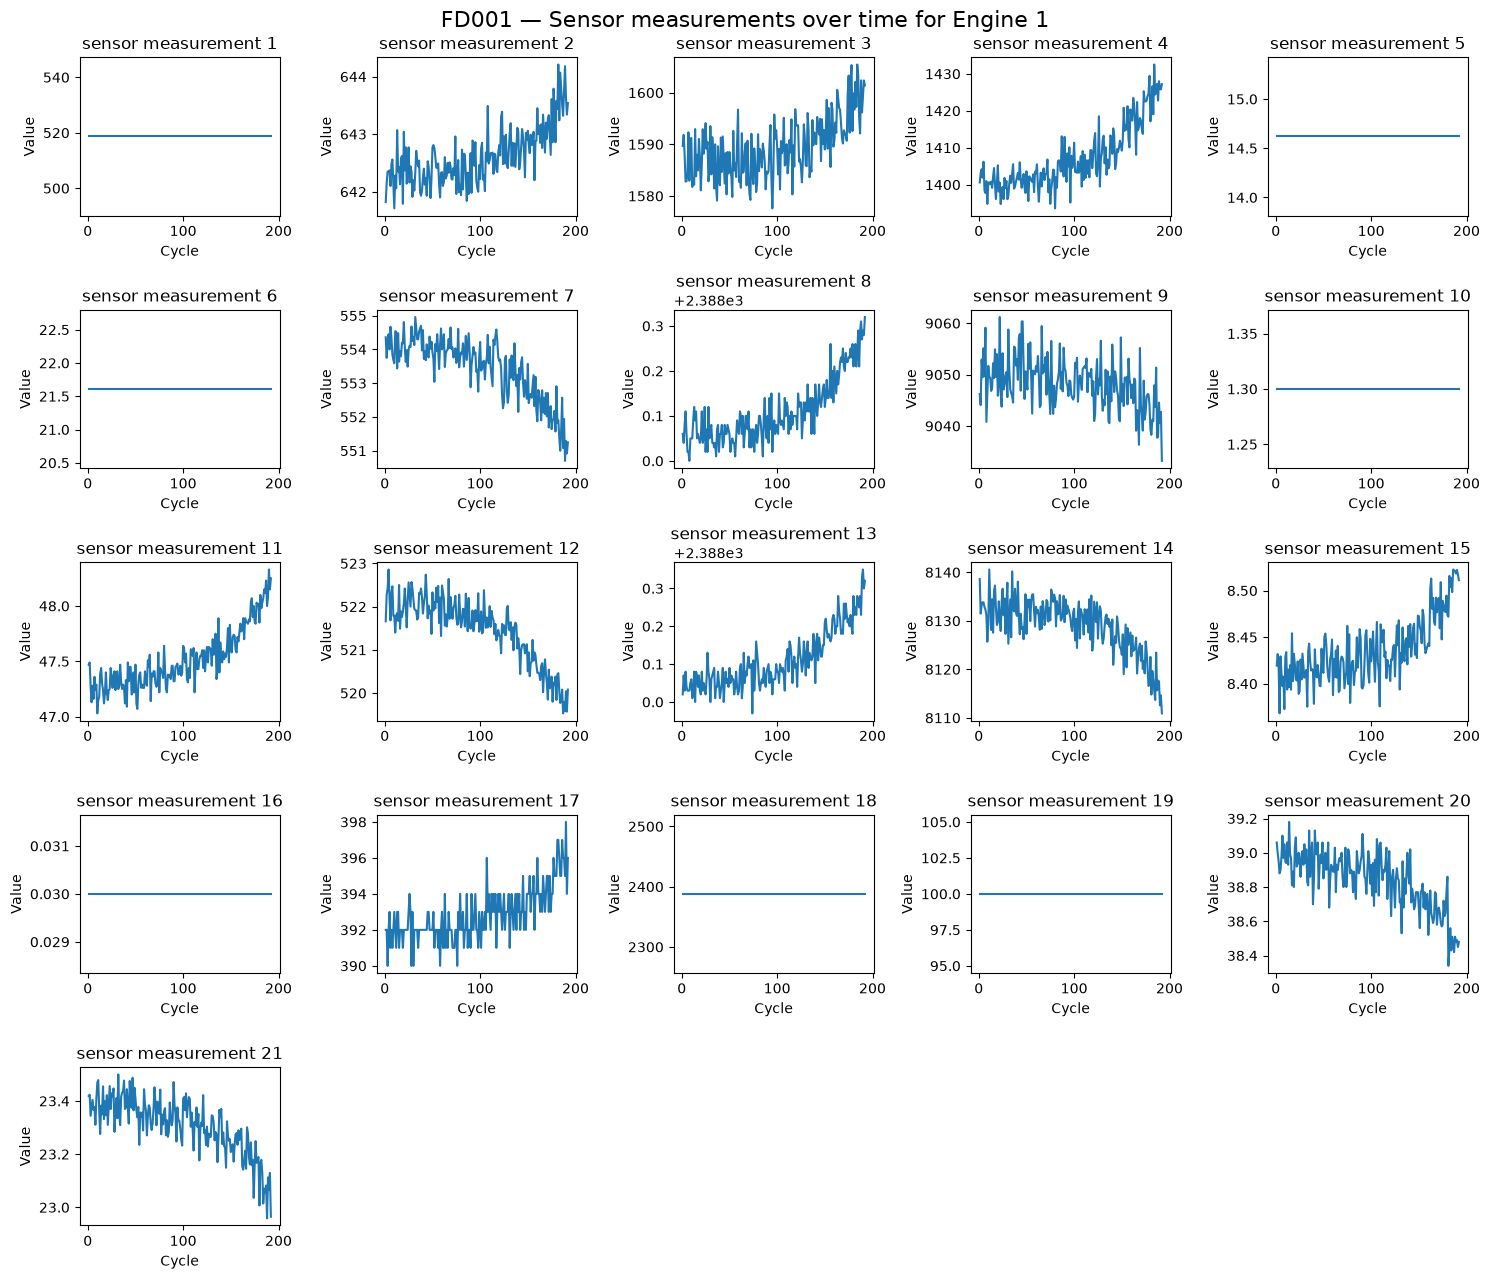

In [109]:
fd = "FD001"

engine = train[fd][
    train[fd]["unit number"] == 1
]

fig, axes = plt.subplots(
    5,
    5,
    figsize=(15, 13)
)

axes = axes.flatten()

for i, sensor in enumerate(sensor_columns):

    axes[i].plot(
        engine["time in cycles"],
        engine[sensor]
    )

    axes[i].set_title(sensor)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Value")

# Hide unused subplot
for i in range(len(sensor_columns), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "FD001 — Sensor measurements over time for Engine 1",
    fontsize=16
)

plt.tight_layout()
plt.show()

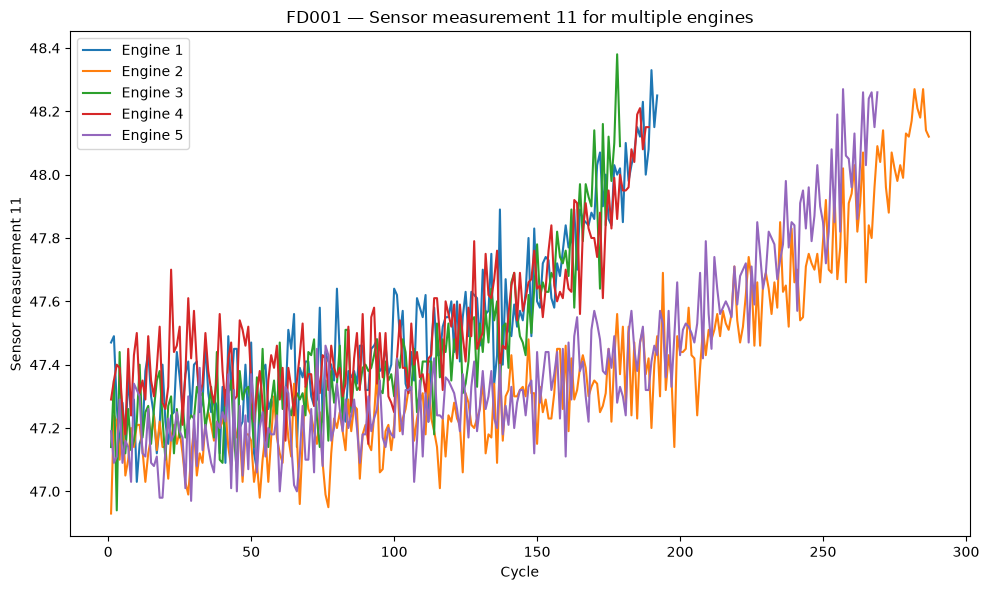

In [110]:
fd = "FD001"

plt.figure(figsize=(10, 6))

for unit in range(1,6):

    engine = train[fd][
        train[fd]["unit number"] == unit
    ]

    plt.plot(
        engine["time in cycles"],
        engine["sensor measurement 11"],
        label=f"Engine {unit}"
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor measurement 11")
plt.title(
    "FD001 — Sensor measurement 11 for multiple engines"
)

plt.legend()

plt.tight_layout()
plt.show()

### Issue identification

#### Missing values

In [111]:
for fd in train:

    print(f"\n{fd}")

    train_missing = train[fd].isna().sum()
    test_missing = test[fd].isna().sum()

    print("Train missing values:", train_missing.sum())
    print("Test missing values: ", test_missing.sum())

    if train_missing.sum() > 0:
        print("\nTrain missing by variable:")
        print(train_missing[train_missing > 0])

    if test_missing.sum() > 0:
        print("\nTest missing by variable:")
        print(test_missing[test_missing > 0])


FD001
Train missing values: 0
Test missing values:  0

FD002
Train missing values: 0
Test missing values:  0

FD003
Train missing values: 0
Test missing values:  0

FD004
Train missing values: 0
Test missing values:  0


The dataset does not have any missing values.

#### Series synchronicity

In [112]:
for fd in train:

    trajectory_lengths = (
        train[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )

    print(f"\n{fd}")
    print(f"Number of engines: {len(trajectory_lengths)}")
    print(f"Minimum length:    {trajectory_lengths.min()}")
    print(f"Maximum length:    {trajectory_lengths.max()}")
    print(f"Mean length:       {trajectory_lengths.mean():.1f}")
    print(f"Median length:     {trajectory_lengths.median():.1f}")


FD001
Number of engines: 100
Minimum length:    128
Maximum length:    362
Mean length:       206.3
Median length:     199.0

FD002
Number of engines: 260
Minimum length:    128
Maximum length:    378
Mean length:       206.8
Median length:     199.0

FD003
Number of engines: 100
Minimum length:    145
Maximum length:    525
Mean length:       247.2
Median length:     220.5

FD004
Number of engines: 249
Minimum length:    128
Maximum length:    543
Mean length:       246.0
Median length:     234.0


The train data consist of separate time series for individual engines. All engine trajectories start at cycle 1, but they have different numbers of cycles and therefore different endpoints. Consequently, the time series are not synchronized at the end.

#### Constant sensor outputs

In [113]:
for fd in train:

    print(f"\n{fd}")

    unique_values = train[fd].nunique()

    print("\nVariables with only one unique value:")

    print(
        unique_values[
            unique_values == 1
        ]
    )


FD001

Variables with only one unique value:
operational setting 3    1
sensor measurement 1     1
sensor measurement 5     1
sensor measurement 10    1
sensor measurement 16    1
sensor measurement 18    1
sensor measurement 19    1
dtype: int64

FD002

Variables with only one unique value:
Series([], dtype: int64)

FD003

Variables with only one unique value:
operational setting 3    1
sensor measurement 1     1
sensor measurement 5     1
sensor measurement 16    1
sensor measurement 18    1
sensor measurement 19    1
dtype: int64

FD004

Variables with only one unique value:
Series([], dtype: int64)


Several sensors have a constant output in set 1 and 3 in both the training and testing datasets.

## PCA

### Building the X matrix

Combining all four training datasets

In [114]:
import numpy as np
from sklearn.cluster import KMeans

In [115]:
combined_frames = []

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    df = train[fd].copy()
    df["dataset"] = fd
    combined_frames.append(df)

combined = pd.concat(combined_frames, ignore_index=True)

print("Combined shape:", combined.shape)
print()
print("Rows per dataset:")
print(combined["dataset"].value_counts())

Combined shape: (160359, 27)

Rows per dataset:
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64


## Identify operating conditons via clustering
FD002 and FD004 fly across 6 operating conditions that change cycle-to-cycle, while FD001/FD003 fly a single condition throughout. We cluster on the operational settings to identify these condtions, which we'll use later to remove the operating-condition confound from the sensor readings.

In [116]:
setting_columns = [
    "operational setting 1",
    "operational setting 2",
    "operational setting 3",
]

settings = combined[setting_columns]

kmeans = KMeans(n_clusters=6, random_state=0, n_init=10)
combined["conditions"] = kmeans.fit_predict(settings)

print(combined["conditions"].value_counts())

conditions
0    62633
1    28853
3    17320
4    17213
5    17199
2    17141
Name: count, dtype: int64


### Quick check: sensor values cluster by operating regime

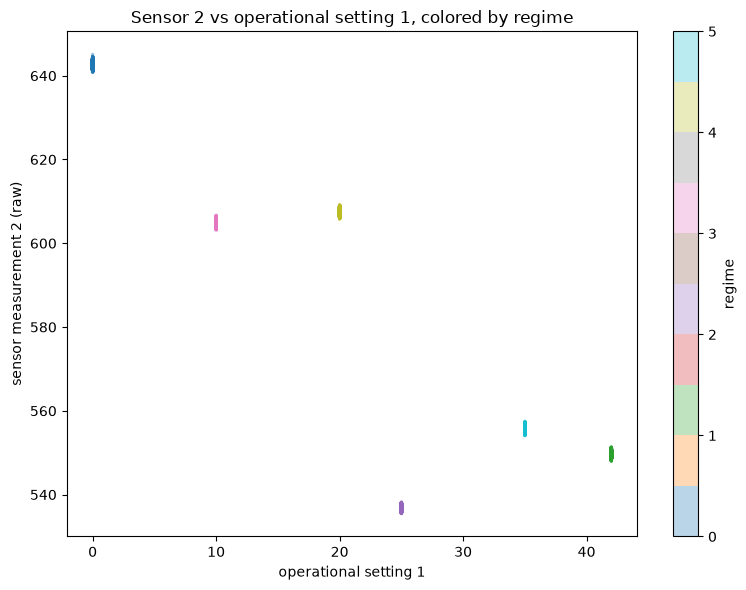

In [117]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    combined["operational setting 1"],
    combined["sensor measurement 2"],
    c=combined["conditions"],
    cmap="tab10",
    s=2,
    alpha=0.3,
)

ax.set_xlabel("operational setting 1")
ax.set_ylabel("sensor measurement 2 (raw)")
ax.set_title("Sensor 2 vs operational setting 1, colored by regime")

plt.colorbar(scatter, label="regime")
plt.tight_layout()
plt.savefig("conditions_confound_check.png", dpi=300, bbox_inches="tight")
plt.show()

## Build the raw (unnormalized) X matrix

In [118]:
sensor_columns = [f"sensor measurement {i}" for i in range(1, 22)]

X_raw_unnorm = combined[sensor_columns].copy()

# Drop near-constant sensors
X_raw_unnorm = X_raw_unnorm.drop(columns=[
    "sensor measurement 1", "sensor measurement 5",
    "sensor measurement 18", "sensor measurement 19"
])

print(X_raw_unnorm.shape)
X_raw_unnorm.describe().T[["mean", "std"]]

(160359, 17)


,mean,std
sensor measurement 2,597.361022,42.478516
sensor measurement 3,1467.035653,118.175261
sensor measurement 4,1260.956434,136.300073
sensor measurement 6,14.424935,6.443922
sensor measurement 7,359.729968,174.133835
sensor measurement 8,2273.829707,142.426613
sensor measurement 9,8677.553696,374.657454
sensor measurement 10,1.153705,0.142103
sensor measurement 11,44.212049,3.426342
sensor measurement 12,338.789821,164.193480


### Autoscale and run SVD (raw data)

In [119]:
X_raw_scaled = (X_raw_unnorm - X_raw_unnorm.mean()) / X_raw_unnorm.std()

U_raw, S_raw, Vt_raw = np.linalg.svd(X_raw_scaled, full_matrices=False)

T_raw = U_raw * S_raw   # scores
P_raw = Vt_raw.T        # loadings

explained_raw = (S_raw ** 2) / np.sum(S_raw ** 2)
print("Variance explained by first 5 PCs:", explained_raw[:5])

Variance explained by first 5 PCs: [0.87611875 0.10470467 0.01335819 0.00277345 0.00164942]


### Scree plot (raw PCA)

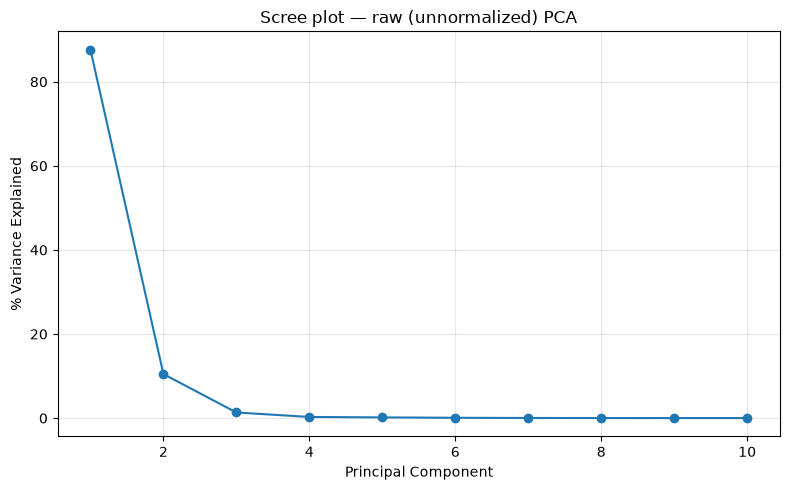

Cumulative variance explained:
[87.61187489 98.08234198 99.41816129 99.69550623 99.86044829 99.93719179
 99.96708574 99.98057866 99.98716304 99.99265947]


In [120]:
fig, ax = plt.subplots(figsize=(8, 5))

n_show = 10
ax.plot(range(1, n_show + 1), explained_raw[:n_show] * 100, "o-")
ax.set_xlabel("Principal Component")
ax.set_ylabel("% Variance Explained")
ax.set_title("Scree plot — raw (unnormalized) PCA")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scree_raw.png", dpi=300, bbox_inches="tight")
plt.show()

print("Cumulative variance explained:")
print(np.cumsum(explained_raw[:n_show]) * 100)

### Scores plot (raw PCA), colored by dataset

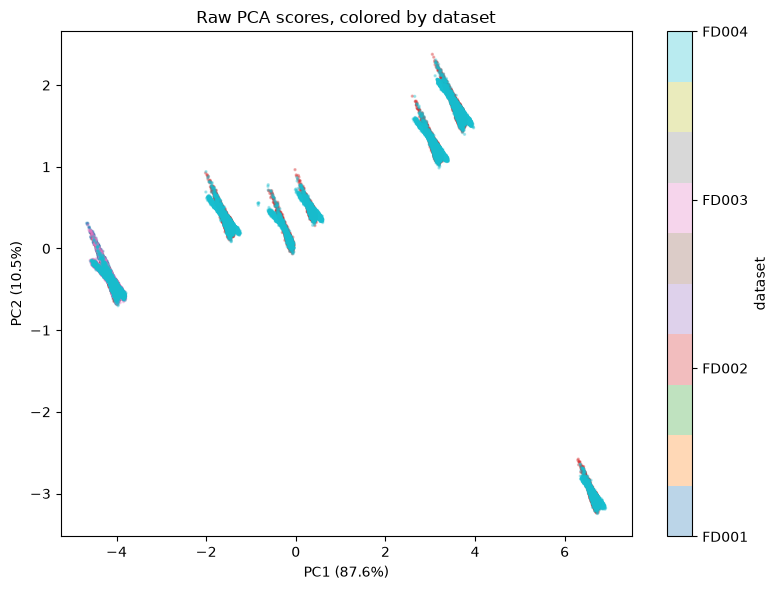

In [121]:
fig, ax = plt.subplots(figsize=(8, 6))

dataset_codes = combined["dataset"].astype("category").cat.codes
dataset_labels = combined["dataset"].astype("category").cat.categories

scatter = ax.scatter(
    T_raw[:, 0],
    T_raw[:, 1],
    c=dataset_codes,
    cmap="tab10",
    s=2,
    alpha=0.3,
)

ax.set_xlabel(f"PC1 ({explained_raw[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_raw[1]*100:.1f}%)")
ax.set_title("Raw PCA scores, colored by dataset")

cbar = plt.colorbar(scatter, ticks=range(len(dataset_labels)))
cbar.ax.set_yticklabels(dataset_labels)
cbar.set_label("dataset")

plt.tight_layout()
plt.savefig("raw_scores_by_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** PC1 alone explains ~87.6% of variance in the raw data, and the scores plot shows 6 tightly separated, non-overlapping clusters corresponding to operating condtions. Confirming that raw PCA is dominated by operating condition rather than engine degradation.

## After normalization: PCA on conditions-normalized data

In [122]:
condition_means = combined.groupby("conditions")[sensor_columns].transform("mean")
combined_normalized = combined.copy()
combined_normalized[sensor_columns] = combined[sensor_columns] - condition_means

combined_normalized[sensor_columns].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
sensor measurement 1,-6.101596e-15,1.759568e-14,-5.684342e-14,0.000000
sensor measurement 2,-3.133568e-14,4.898674e-01,-1.765438e+00,2.544562
sensor measurement 3,-9.982045e-16,6.322369e+00,-2.494986e+01,27.660142
sensor measurement 4,1.814917e-16,8.926482e+00,-2.955972e+01,34.870279
sensor measurement 5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
sensor measurement 6,3.431328e-16,1.330220e-02,-1.527444e-01,0.022467
sensor measurement 7,4.991022e-15,1.986426e+00,-5.285404e+00,16.484612
sensor measurement 8,-9.036444e-14,1.957367e-01,-1.185408e+00,2.219195
sensor measurement 9,1.203630e-13,1.864412e+01,-4.630849e+01,180.361508
sensor measurement 10,-5.374743e-17,3.801778e-03,-1.200826e-02,0.038541


### Build the X matrix (sensors only, no operational settings)

In [123]:
feature_columns = sensor_columns  # sensors only, no operational settings

X_raw = combined_normalized[feature_columns].copy()

stds = X_raw.std()
near_constant = stds[stds < 1e-6].index.tolist()
print("Dropping near-constant columns:", near_constant)

X_raw = X_raw.drop(columns=near_constant)

print(X_raw.shape)
X_raw.describe().T[["mean", "std"]]

Dropping near-constant columns: ['sensor measurement 1', 'sensor measurement 5', 'sensor measurement 18', 'sensor measurement 19']
(160359, 17)


,mean,std
sensor measurement 2,-3.133568e-14,0.489867
sensor measurement 3,-9.982045e-16,6.322369
sensor measurement 4,1.814917e-16,8.926482
sensor measurement 6,3.431328e-16,0.013302
sensor measurement 7,4.991022e-15,1.986426
sensor measurement 8,-9.036444e-14,0.195737
sensor measurement 9,1.203630e-13,18.644122
sensor measurement 10,-5.374743e-17,0.003802
sensor measurement 11,-9.074586e-17,0.274977
sensor measurement 12,-1.306740e-14,1.858804


### Autoscale and run SVD (regime-normalized data)

In [124]:
X_norm_scaled = (X_raw - X_raw.mean()) / X_raw.std()

U_norm, S_norm, Vt_norm = np.linalg.svd(X_norm_scaled, full_matrices=False)

T_norm = U_norm * S_norm
P_norm = Vt_norm.T

explained_norm = (S_norm ** 2) / np.sum(S_norm ** 2)
print("Variance explained by first 5 PCs:", explained_norm[:5])

Variance explained by first 5 PCs: [0.33470994 0.29663369 0.08069254 0.05672065 0.0443339 ]


### Scree plot (regime-normalized PCA)

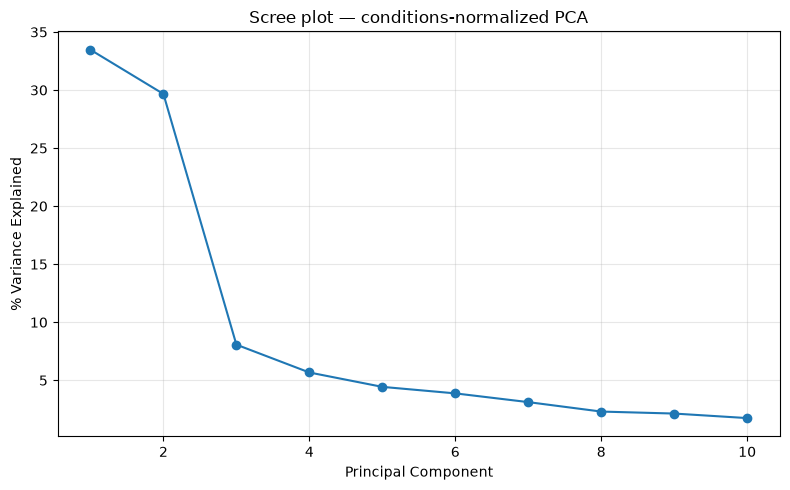

Cumulative variance explained:
[33.47099404 63.13436266 71.20361626 76.87568165 81.30907137 85.18192525
 88.30176148 90.60769379 92.7424622  94.48750444]


In [125]:
fig, ax = plt.subplots(figsize=(8, 5))

n_show = 10
ax.plot(range(1, n_show + 1), explained_norm[:n_show] * 100, "o-")
ax.set_xlabel("Principal Component")
ax.set_ylabel("% Variance Explained")
ax.set_title("Scree plot — conditions-normalized PCA")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scree_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

print("Cumulative variance explained:")
print(np.cumsum(explained_norm[:n_show]) * 100)

### Scores plot (regime-normalized PCA), colored by dataset

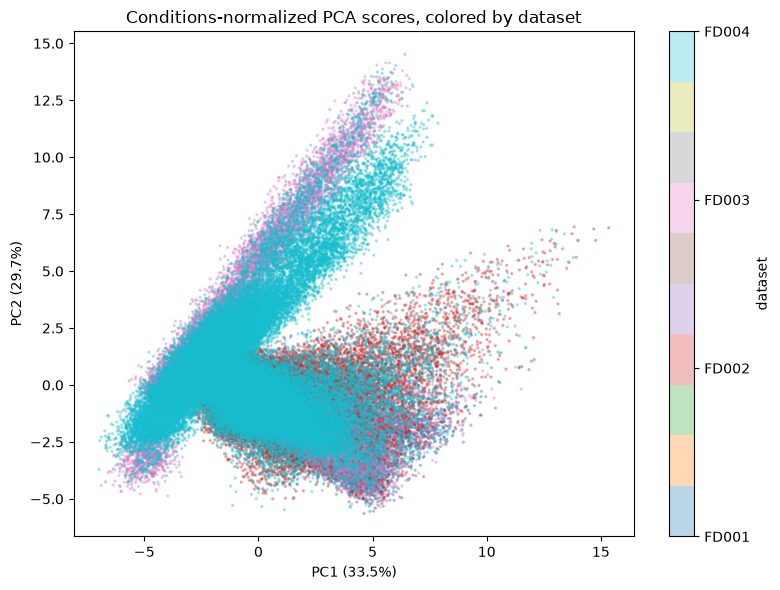

In [126]:
fig, ax = plt.subplots(figsize=(8, 6))

dataset_codes = combined["dataset"].astype("category").cat.codes
dataset_labels = combined["dataset"].astype("category").cat.categories

scatter = ax.scatter(
    T_norm[:, 0],
    T_norm[:, 1],
    c=dataset_codes,
    cmap="tab10",
    s=2,
    alpha=0.3,
)

ax.set_xlabel(f"PC1 ({explained_norm[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_norm[1]*100:.1f}%)")
ax.set_title("Conditions-normalized PCA scores, colored by dataset")

cbar = plt.colorbar(scatter, ticks=range(len(dataset_labels)))
cbar.ax.set_yticklabels(dataset_labels)
cbar.set_label("dataset")

plt.tight_layout()
plt.savefig("normalized_scores_by_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** After condition normalization, PC1 drops to ~28.5% of variance and the 6 operating conditions clusters are no longer separated. Confirming the operating-condition confound has been removed. Instead, the scores form a branching shape: one arm reaching toward high PC2, another toward high PC1.

### Cumulative variance explained (condtions-normalized PCA)

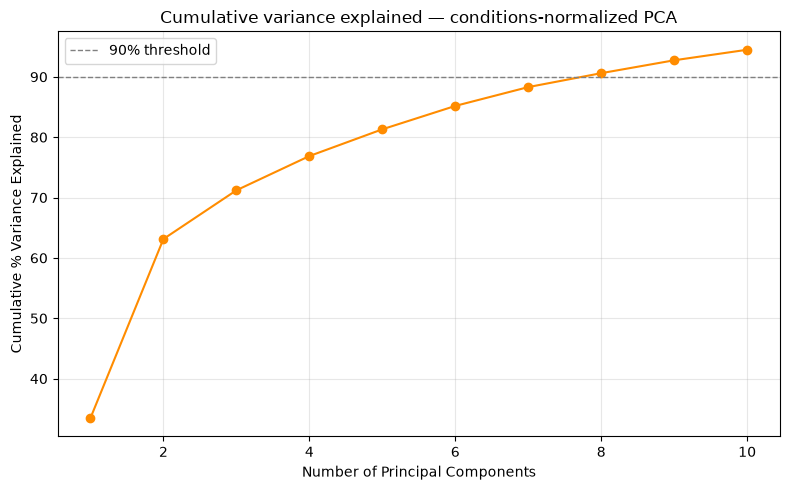

In [127]:
fig, ax = plt.subplots(figsize=(8, 5))

n_show = 10
cumulative = np.cumsum(explained_norm[:n_show]) * 100

ax.plot(range(1, n_show + 1), cumulative, "o-", color="darkorange")
ax.axhline(90, color="grey", linestyle="--", linewidth=1, label="90% threshold")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative % Variance Explained")
ax.set_title("Cumulative variance explained — conditions-normalized PCA")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cumulative_variance_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

### Quantifying which datasets populate each arm

In [128]:
scores_df = pd.DataFrame({
    "PC1": T_norm[:, 0],
    "PC2": T_norm[:, 1],
    "dataset": combined["dataset"].values,
})

upper_arm = scores_df[(scores_df["PC2"] > 7) & (scores_df["PC1"] < 5)]
lower_arm = scores_df[(scores_df["PC1"] > 5) & (scores_df["PC2"] < 5)]

print("Upper arm (high PC2) — dataset proportions:")
print(upper_arm["dataset"].value_counts(normalize=True).round(3))

print("\nLower-right arm (high PC1) — dataset proportions:")
print(lower_arm["dataset"].value_counts(normalize=True).round(3))

print("\nOverall dataset proportions (for reference):")
print(combined["dataset"].value_counts(normalize=True).round(3))

Upper arm (high PC2) — dataset proportions:
dataset
FD003    0.511
FD004    0.489
Name: proportion, dtype: float64

Lower-right arm (high PC1) — dataset proportions:
dataset
FD002    0.449
FD004    0.260
FD001    0.196
FD003    0.095
Name: proportion, dtype: float64

Overall dataset proportions (for reference):
dataset
FD004    0.382
FD002    0.335
FD003    0.154
FD001    0.129
Name: proportion, dtype: float64


**Observation:** the upper arm is populated almost exclusively by FD003/FD004 (both have fan + HPC degradation), while the lower-right arm leans toward FD001/FD002 (HPC-only degradation). Suggesting PC2 captures a fault-mode signature distinguishing single vs. dual degradation pathways.

### Biplot: conditions-normalized PCA scores and loadings

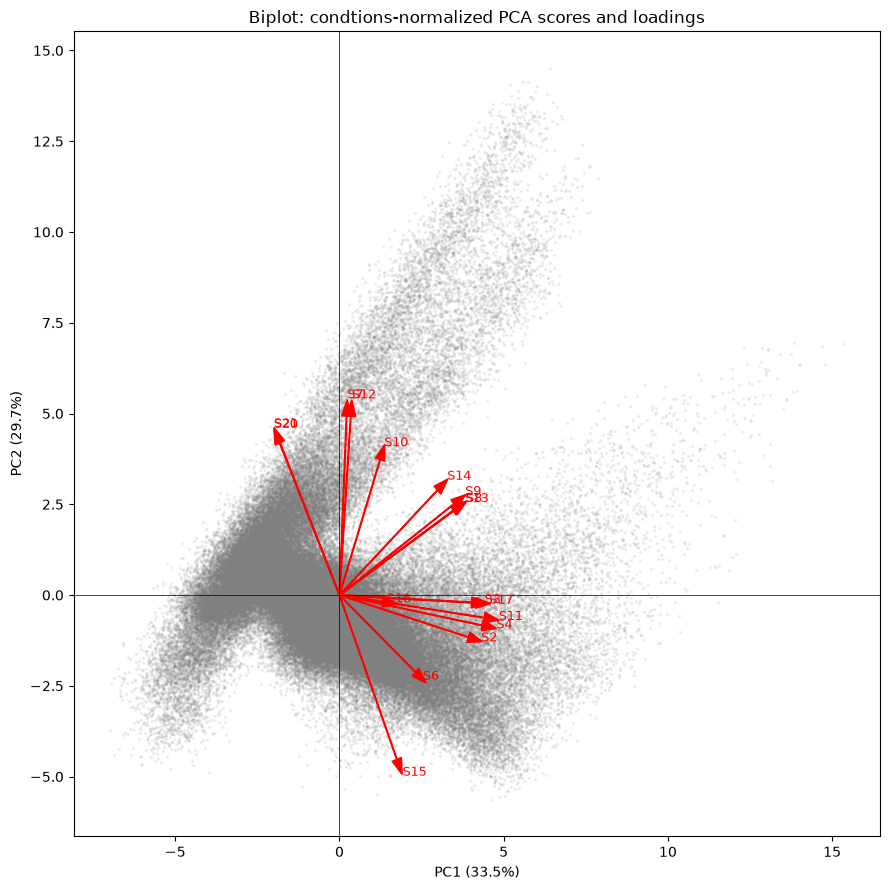

In [129]:
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(
    T_norm[:, 0],
    T_norm[:, 1],
    s=2,
    alpha=0.1,
    color="grey",
)

scale = np.max(np.abs(T_norm[:, :2])) * 0.8

for i, sensor in enumerate(X_raw.columns):
    ax.arrow(
        0, 0,
        P_norm[i, 0] * scale,
        P_norm[i, 1] * scale,
        color="red",
        width=0.02,
        head_width=0.3,
    )
    ax.text(
        P_norm[i, 0] * scale * 1.1,
        P_norm[i, 1] * scale * 1.1,
        sensor.replace("sensor measurement ", "S"),
        color="red",
        fontsize=9,
    )

ax.set_xlabel(f"PC1 ({explained_norm[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_norm[1]*100:.1f}%)")
ax.set_title("Biplot: condtions-normalized PCA scores and loadings")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("biplot_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

### Correlation matrix of sensors (conditions-normalized)

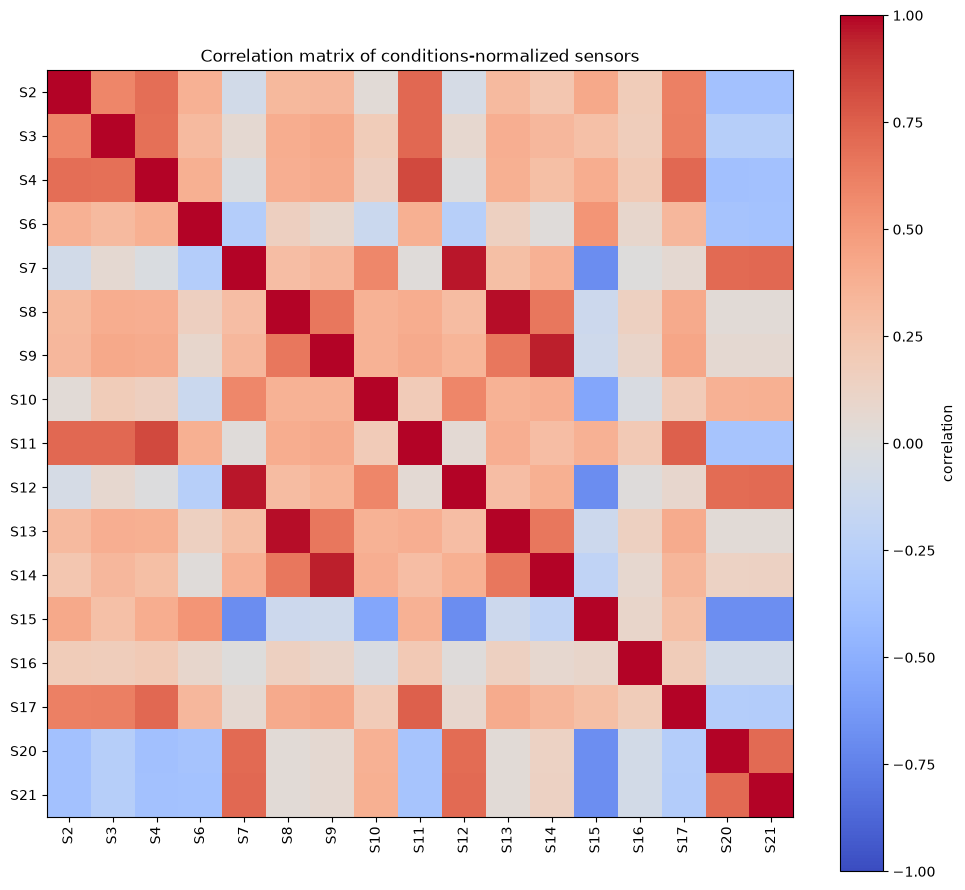

In [130]:
corr_matrix = X_raw.corr()

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(
    [c.replace("sensor measurement ", "S") for c in corr_matrix.columns],
    rotation=90
)
ax.set_yticklabels(
    [c.replace("sensor measurement ", "S") for c in corr_matrix.columns]
)

ax.set_title("Correlation matrix of conditions-normalized sensors")
plt.colorbar(im, label="correlation")
plt.tight_layout()
plt.savefig("sensor_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Observation: sensors group into roughly 6-7 correlated blocks (e.g. S2/S3/S4/S11/S17; S8/S9/S13/S14; S7/S12; S20/S21), with S15 and S16 largely standalone, indicating substantial redundancy among the 17 sensors.

## Pretreatment plan

- **Centering and autoscaling:** All sensor variables are centered (mean subtracted) and scaled to unit variance before PCA, since sensors are on very different physical scales.
- **Constant/near-constant sensors:** Sensors with (near) zero variance (S1, S5, S18, S19) are dropped, as they carry no information and would cause division-by-zero issues during scaling.
- **Condition normalization:** FD002/FD004 operate across 6 changing flight conditions (unlike FD001/FD003's single condition), which confounds raw sensor readings with degradation. We cluster operating conditions via k-means and subtract each regime's mean from the sensors before PCA, removing this confound.
- **Operational settings excluded from PCA input:** Settings are only used to define regimes; including them directly in PCA would reintroduce the condition-driven variation we just removed.
